# BDC Satria Data 2026 - MBG Tweet Classification

## Ensemble IndoBERT + IndoBERTweet

**Kelas:** `Anggaran` | `Kualitas Pangan` | `Distribusi` | `Ekonomi` | `Tata Kelola` | `Sasaran Penerima` | `Politik` | `Lainnya`

**Metrik:** Balanced Accuracy

Strategi notebook ini:
- Fine-tune `indobenchmark/indobert-base-p2` dan `indolem/indobertweet-base-uncased`
- Jalankan dua learning rate: `2e-5`, `3e-5`
- Kumpulkan OOF probability dari Stratified K-Fold
- Buat dua ensemble: soft voting dan stacking

## 1. Install dan Import Library

In [1]:
# Install dependensi
# !pip install transformers datasets sentencepiece scipy scikit-learn openpyxl saka-nlp -q

import os, re, json, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW

from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    logging as hf_logging,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from scipy.optimize import minimize
from huggingface_hub.utils import logging as hub_logging

import saka

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
hub_logging.set_verbosity_error()

SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"saka version: {saka.__version__}")
print("Library siap.")

Device : cuda
GPU  : Tesla T4
VRAM : 15.64 GB
saka version: 0.1.9
Library siap.


## 2. Konfigurasi Global

In [2]:
# Konfigurasi Ensemble IndoBERT + IndoBERTweet

# Paths: otomatis cocok untuk Kaggle dan local workspace.
def resolve_data_dir():
    candidates = [
        Path("/kaggle/input/datasets/tahtaaunillah/dataset"),
        Path("case-1/dataset"),
        Path("dataset"),
    ]
    for path in candidates:
        if (path / "case_1_labeled_data.xlsx").exists():
            return path
    raise FileNotFoundError("Dataset case_1_labeled_data.xlsx tidak ditemukan.")


DATA_DIR = resolve_data_dir()
LABELED_FILE = DATA_DIR / "case_1_labeled_data.xlsx"
PREDICT_FILE = DATA_DIR / "case_1_text_to_predict.xlsx"
TEMPLATE_FILE = DATA_DIR / "case_1_template_sheet.xlsx"

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR = Path("checkpoints_indobert_indobertweet")
CHECKPOINT_DIR.mkdir(exist_ok=True)

OOF_PROB_FILE = OUTPUT_DIR / "oof_probs_indobert_indobertweet.npy"
TEST_PROB_FILE = OUTPUT_DIR / "test_probs_indobert_indobertweet.npy"
MANIFEST_FILE = OUTPUT_DIR / "manifest_indobert_indobertweet.json"

# Model ensemble heterogen: IndoBERT formal + IndoBERTweet informal.
MODEL_CONFIGS = [
    {"alias": "indobert", "model_name": "indobenchmark/indobert-base-p2"},
    {"alias": "indobertweet", "model_name": "indolem/indobertweet-base-uncased"},
]
LEARNING_RATES = [2e-5, 3e-5]

# Training
MAX_LENGTH = 128
N_FOLDS = 5
BATCH_SIZE = 32
NUM_EPOCHS = 8
WEIGHT_DECAY = 0.05
OPTIMIZER_NAME = "AdamW"
DROPOUT_RATE = 0.1
FREEZE_BOTTOM_N_LAYERS = 0
HEAD_LR_MULTIPLIER = 1.0
EARLY_STOPPING_METRIC = "balanced_accuracy"
EARLY_STOPPING_GREATER_IS_BETTER = True
WARMUP_RATIO = 0.1
EARLY_STOPPING_PAT = 3
LABEL_SMOOTHING = 0.1

# Fold-local augmentation: hanya untuk train split, validation/test tetap bersih.
USE_FOLD_AUGMENTATION = True
ECONOMY_AUG_TARGET_PER_FOLD = 300
LAINNYA_SHORT_AUG_TARGET_PER_FOLD = 0
LAINNYA_SHORT_TOKEN_THRESHOLD = 10
AUGMENTATION_RANDOM_SEED = SEED + 2026

# Imbalance handling
USE_WEIGHTED_SAMPLER = True
SAMPLER_ALPHA = 0.5
EFFECTIVE_NUM_BETA = 0.999
MAX_CLASS_WEIGHT = 4.0
VS_IOTA = 0.05
VS_TAU = 0.5

# Output
TEAM_NAME = "Last_Dance_DS"
VOTING_SUBMISSION_FILE = OUTPUT_DIR / f"{TEAM_NAME}_voting.xlsx"
STACKING_SUBMISSION_FILE = OUTPUT_DIR / f"{TEAM_NAME}_stacking.xlsx"
SUBMISSION_FILE = STACKING_SUBMISSION_FILE

# Label mapping
LABEL_NAMES = [
    "Anggaran", "Kualitas Pangan", "Distribusi", "Ekonomi",
    "Tata Kelola", "Sasaran Penerima", "Politik", "Lainnya",
]
NUM_LABELS = len(LABEL_NAMES)

print("Konfigurasi Ensemble IndoBERT + IndoBERTweet")
print(f"Data dir   : {DATA_DIR}")
print(f"Backbones  : {[m['model_name'] for m in MODEL_CONFIGS]}")
print(f"LR grid    : {LEARNING_RATES}")
print(f"Total run  : {len(MODEL_CONFIGS) * len(LEARNING_RATES)} base learners")
print(f"Folds      : {N_FOLDS} | Epochs: {NUM_EPOCHS} | Patience: {EARLY_STOPPING_PAT}")
print(f"Optimizer  : {OPTIMIZER_NAME} | Weight decay: {WEIGHT_DECAY}")
print(f"Regularize : dropout={DROPOUT_RATE} | freeze bottom={FREEZE_BOTTOM_N_LAYERS} | head LR x{HEAD_LR_MULTIPLIER:g}")
print(f"Early stop : {EARLY_STOPPING_METRIC} | Patience: {EARLY_STOPPING_PAT} | greater_is_better={EARLY_STOPPING_GREATER_IS_BETTER}")
print(f"Augment    : fold-local={USE_FOLD_AUGMENTATION} | ekonomi target={ECONOMY_AUG_TARGET_PER_FOLD} | lainnya-short target={LAINNYA_SHORT_AUG_TARGET_PER_FOLD}")
print(f"MAX_LENGTH : {MAX_LENGTH}")

Konfigurasi Ensemble IndoBERT + IndoBERTweet
Data dir   : /kaggle/input/datasets/tahtaaunillah/dataset
Backbones  : ['indobenchmark/indobert-base-p2', 'indolem/indobertweet-base-uncased']
LR grid    : [2e-05, 3e-05]
Total run  : 4 base learners
Folds      : 5 | Epochs: 8 | Patience: 3
Optimizer  : AdamW | Weight decay: 0.05
Regularize : dropout=0.1 | freeze bottom=0 | head LR x1
Early stop : balanced_accuracy | Patience: 3 | greater_is_better=True
Augment    : fold-local=True | ekonomi target=300 | lainnya-short target=0
MAX_LENGTH : 128


## 3. Ingesti Data dan Audit Struktur

In [3]:
df_train = pd.read_excel(LABELED_FILE)
df_test = pd.read_excel(PREDICT_FILE)
df_tmpl = pd.read_excel(TEMPLATE_FILE)

print(f"Train    : {df_train.shape[0]:,} x {df_train.shape[1]}")
print(f"Test     : {df_test.shape[0]:,} x {df_test.shape[1]}")
print(f"Template : {df_tmpl.shape[0]:,} x {df_tmpl.shape[1]}")

print("\nDistribusi kelas")
class_counts = df_train["label"].value_counts()
print(class_counts)
print(f"\nRasio imbalance (max/min): {class_counts.max() / class_counts.min():.2f}x")


Train    : 5,000 x 2
Test     : 1,500 x 2
Template : 1,500 x 2

Distribusi kelas
label
Kualitas Pangan     1247
Politik              792
Anggaran             727
Lainnya              638
Tata Kelola          511
Sasaran Penerima     507
Distribusi           433
Ekonomi              145
Name: count, dtype: int64

Rasio imbalance (max/min): 8.60x


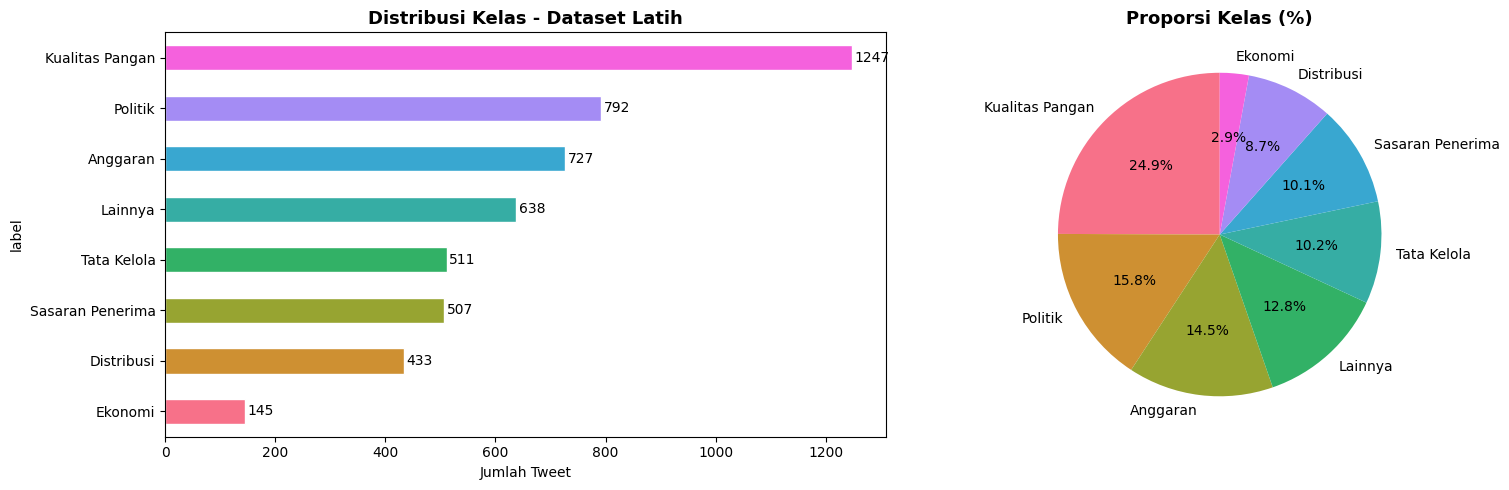

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = sns.color_palette("husl", NUM_LABELS)
class_counts.sort_values().plot(kind="barh", ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("Distribusi Kelas - Dataset Latih", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Jumlah Tweet")
for i, v in enumerate(class_counts.sort_values()):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=10)
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Proporsi Kelas (%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution_v5.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
le = LabelEncoder()
le.fit(LABEL_NAMES)
df_train["label_id"] = le.transform(df_train["label"])
label2id = {lbl: idx for idx, lbl in enumerate(le.classes_)}
id2label = {idx: lbl for lbl, idx in label2id.items()}

class_counts_arr = np.array([(df_train["label_id"] == i).sum() for i in range(NUM_LABELS)])
class_weights = compute_class_weight("balanced", classes=np.arange(NUM_LABELS), y=df_train["label_id"].values)
class_weights_t = torch.tensor(class_weights, dtype=torch.float)

print("Label to ID mapping:")
for lbl, idx in sorted(label2id.items(), key=lambda x: x[1]):
    cnt = class_counts_arr[idx]
    pct = cnt / len(df_train) * 100
    bar = "#" * (cnt // 80)
    print(f"[{idx}] {lbl:<22}: {cnt:>5} ({pct:4.1f}%)  {bar}")
print(f"\nClass weights: {class_weights.round(4)}")


Label to ID mapping:
[0] Anggaran              :   727 (14.5%)  #########
[1] Distribusi            :   433 ( 8.7%)  #####
[2] Ekonomi               :   145 ( 2.9%)  #
[3] Kualitas Pangan       :  1247 (24.9%)  ###############
[4] Lainnya               :   638 (12.8%)  #######
[5] Politik               :   792 (15.8%)  #########
[6] Sasaran Penerima      :   507 (10.1%)  ######
[7] Tata Kelola           :   511 (10.2%)  ######

Class weights: [0.8597 1.4434 4.3103 0.5012 0.9796 0.7891 1.2327 1.2231]


## 4. Preprocessing (saka-nlp + Domain Gap Dictionary)

## Strategi Pipeline

```text
Raw tweet
  -> [1] Lowercase
  -> [2] Ganti @mention menjadi placeholder usrxtok
  -> [3] Ganti URL menjadi placeholder urlxtok
  -> [4] Hapus simbol hashtag, pertahankan kata
  -> [5] saka.normalize()
  -> [6] Restore usrxtok menjadi [USER], urlxtok menjadi [URL]
  -> [7] DOMAIN_TECH_DICT untuk gap kata kunci teknis MBG
  -> [8] Normalisasi elongasi ekstrem
  -> [9] Normalisasi whitespace
  -> Teks bersih
```

Placeholder dipakai sebelum `saka.normalize()` agar mention dan URL tidak hilang atau salah diproses.


In [6]:
DOMAIN_PHRASE_DICT = {
    "mkn brgz": "makan bergizi gratis",
    "makan gratis": "makan bergizi gratis",
    "program makan": "program makan bergizi gratis",
}

DOMAIN_TOKEN_DICT = {
    # Anggaran
    "anggrn": "anggaran",
    "angaran": "anggaran",
    "anggran": "anggaran",
    "apbn": "anggaran pendapatan belanja negara",
    "apbd": "anggaran pendapatan belanja daerah",
    "rapbn": "rancangan anggaran pendapatan belanja negara",

    # Ekonomi
    "umkm": "usaha mikro kecil menengah",
    "kur": "kredit usaha rakyat",
    "bri": "bank rakyat indonesia",
    "bumn": "badan usaha milik negara",

    # Tata Kelola
    "tatkelola": "tata kelola",
    "tatakelola": "tata kelola",
    "pokja": "kelompok kerja",
    "bpk": "badan pemeriksa keuangan",
    "kpk": "komisi pemberantasan korupsi",

    # Sasaran Penerima
    "pnerima": "penerima",
    "penrima": "penerima",
    "pnrima": "penerima",

    # Distribusi
    "sppg": "satuan pelayanan pemenuhan gizi",
    "logstik": "logistik",

    # Program MBG
    "mbg": "makan bergizi gratis",
}


def apply_domain_phrases(text: str) -> str:
    for phrase, repl in DOMAIN_PHRASE_DICT.items():
        text = re.sub(rf"\b{re.escape(phrase)}\b", repl, text)
    return text


def clean_text_v5(text: str) -> str:
    """Pipeline preprocessing V5 dengan saka-nlp, domain phrase, dan token dictionary."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"@\w+", "usrxtok", text)
    text = re.sub(r"https?://\S+|www\.\S+", "urlxtok", text)
    text = re.sub(r"#(\w+)", r"\1", text)

    text = saka.normalize(text)

    text = re.sub(r"\busrxtok\b", "[USER]", text)
    text = re.sub(r"\burlxtok\b", "[URL]", text)

    text = apply_domain_phrases(text)
    tokens = text.split()
    tokens = [DOMAIN_TOKEN_DICT.get(tok, tok) for tok in tokens]
    text = " ".join(tokens)

    text = re.sub(r"(.)\1{3,}", r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample_texts = [
    "@ARSIPAJA gw dapet MBG tetep aja anak-anaknya jajan",
    "anggrn APBN buat MBG udah habis utk pnerima yg salah sasaran",
] * 50

t0 = time.time()
_ = [clean_text_v5(s) for s in sample_texts]
elapsed = time.time() - t0
print(f"Kecepatan saka pipeline: {elapsed / len(sample_texts) * 1000:.2f} ms/teks")
print(f"Estimasi 5,000 teks: {elapsed / len(sample_texts) * 5000:.1f}s")
print(f"Estimasi 1,500 teks: {elapsed / len(sample_texts) * 1500:.1f}s")


Kecepatan saka pipeline: 0.05 ms/teks
Estimasi 5,000 teks: 0.2s
Estimasi 1,500 teks: 0.1s


In [7]:
demo_samples = [
    "@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep aja anak-anaknya pada jajan",
    "MBG bentuk penggarongan duit negara secara TSM (Terstruktur-Masif dan Sistempik).",
    "banyaakkkkk banget anak yg gak dpt MBG dri sekolah!!!",
    "wkwk emg programnya geratis tp kualitasnya gmn?? https://t.co/xxx",
    "anggrn APBN buat MBG udah habis utk pnerima yg salah sasaran",
    "tatkelola pokja MBG kacau banget wkwk korupsi dimana-mana",
    "ga tau knp distribusi MBG blm sampe sekolah gue malahan",
    "sy setuju sm programnya tp pelaksanaannya hrs diperbaiki bgt",
]

print("Demo saka-nlp preprocessing pipeline V5:")
print("=" * 75)
for raw in demo_samples:
    clean = clean_text_v5(raw)
    print(f"RAW  : {raw[:75]}")
    print(f"CLEAN: {clean[:75]}")
    print()


Demo saka-nlp preprocessing pipeline V5:
RAW  : @ARSIPAJA Pret. Di sekolah gw dapet MBG tetep aja anak-anaknya pada jajan
CLEAN: [USER] pret di sekolah saya dapat makan bergizi gratis tetep saja anak anak

RAW  : MBG bentuk penggarongan duit negara secara TSM (Terstruktur-Masif dan Siste
CLEAN: makan bergizi gratis bentuk penggarongan duit negara secara tsm terstruktur

RAW  : banyaakkkkk banget anak yg gak dpt MBG dri sekolah!!!
CLEAN: banyaakk banget anak yang gak dapat makan bergizi gratis dari sekolah

RAW  : wkwk emg programnya geratis tp kualitasnya gmn?? https://t.co/xxx
CLEAN: wkwk emg programnya geratis tapi kualitasnya gmn [URL]

RAW  : anggrn APBN buat MBG udah habis utk pnerima yg salah sasaran
CLEAN: anggaran anggaran pendapatan belanja negara buat makan bergizi gratis sudah

RAW  : tatkelola pokja MBG kacau banget wkwk korupsi dimana-mana
CLEAN: tata kelola kelompok kerja makan bergizi gratis kacau banget wkwk korupsi d

RAW  : ga tau knp distribusi MBG blm sampe sekolah 

In [8]:
print("Preprocessing dataset latih dengan saka-nlp...")
t0 = time.time()
df_train["clean_text"] = df_train["full_text"].apply(clean_text_v5)
t1 = time.time()
print(f"Selesai: {t1 - t0:.1f}s ({(t1 - t0) / len(df_train) * 1000:.1f} ms/teks)")

print("Preprocessing dataset uji...")
t2 = time.time()
df_test["clean_text"] = df_test["full_text"].apply(clean_text_v5)
t3 = time.time()
print(f"Selesai: {t3 - t2:.1f}s ({(t3 - t2) / len(df_test) * 1000:.1f} ms/teks)")

for name, df in [("Train", df_train), ("Test", df_test)]:
    empty = (df["clean_text"].str.strip() == "").sum()
    if empty > 0:
        df["clean_text"] = df["clean_text"].replace("", "teks kosong")
        print(f"{empty} baris kosong di {name} diisi placeholder")

lens = df_train["clean_text"].str.split().apply(len)
print("\nPreprocessing V5 selesai.")
print(f"Train: {len(df_train):,} | Test: {len(df_test):,}")
print(f"Token - Mean: {lens.mean():.1f}, Median: {lens.median():.1f}, Max: {lens.max()}, Min: {lens.min()}")

user_count = df_train["clean_text"].str.contains(r"\[USER\]", regex=True).sum()
url_count = df_train["clean_text"].str.contains(r"\[URL\]", regex=True).sum()
print(f"[USER] token: {user_count:,} teks mengandung mention")
print(f"[URL] token: {url_count:,} teks mengandung link")


print("\nPanjang teks per kelas (clean_text):")
text_len_by_class = (
    df_train.assign(token_len=df_train["clean_text"].str.split().apply(len))
    .groupby("label")["token_len"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(LABEL_NAMES)
)
display(text_len_by_class)

ECONOMY_KEYWORDS = [
    "dampak ekonomi", "usaha mikro kecil menengah", "rantai pasok",
    "lapangan kerja", "harga bahan pangan", "petani lokal",
    "tenaga kerja", "daya beli",
]

LAINNYA_NOISE_TOKENS = [
    "umum", "ambigu", "opini singkat", "konteks kurang jelas",
]


def light_token_dropout(text: str, rng: random.Random, drop_prob: float = 0.10, min_keep: int = 4) -> str:
    tokens = str(text).split()
    if len(tokens) <= min_keep:
        return str(text)
    kept = [tok for tok in tokens if rng.random() > drop_prob]
    if len(kept) < min_keep:
        kept = tokens[:min_keep]
    return " ".join(kept)


def augment_economy_text(text: str, rng: random.Random) -> str:
    variant = light_token_dropout(text, rng, drop_prob=0.08, min_keep=5)
    keyword = rng.choice(ECONOMY_KEYWORDS)
    if keyword not in variant:
        variant = f"{variant} {keyword}"
    return re.sub(r"\s+", " ", variant).strip()


def augment_lainnya_short_text(text: str, rng: random.Random) -> str:
    variant = light_token_dropout(text, rng, drop_prob=0.08, min_keep=3)
    if rng.random() < 0.35:
        variant = f"{variant} {rng.choice(LAINNYA_NOISE_TOKENS)}"
    return re.sub(r"\s+", " ", variant).strip()


def augment_training_fold(
    texts,
    labels,
    target_economy=ECONOMY_AUG_TARGET_PER_FOLD,
    target_lainnya_short=LAINNYA_SHORT_AUG_TARGET_PER_FOLD,
    seed=SEED,
):
    """Augmentasi hanya untuk train fold agar validasi tetap bersih."""
    if not USE_FOLD_AUGMENTATION:
        return list(texts), list(labels), {"Ekonomi": 0, "Lainnya_short": 0}

    rng = random.Random(seed)
    aug_texts = list(texts)
    aug_labels = list(labels)
    added = {"Ekonomi": 0, "Lainnya_short": 0}

    ekonomi_id = label2id.get("Ekonomi")
    lainnya_id = label2id.get("Lainnya")

    ekonomi_items = [(t, y) for t, y in zip(texts, labels) if y == ekonomi_id]
    while ekonomi_items and sum(1 for y in aug_labels if y == ekonomi_id) < target_economy:
        base_text, base_label = rng.choice(ekonomi_items)
        aug_texts.append(augment_economy_text(base_text, rng))
        aug_labels.append(base_label)
        added["Ekonomi"] += 1

    if target_lainnya_short > 0:
        lainnya_short_items = [
            (t, y) for t, y in zip(texts, labels)
            if y == lainnya_id and len(str(t).split()) <= LAINNYA_SHORT_TOKEN_THRESHOLD
        ]
        current_lainnya_short = sum(
            1 for t, y in zip(aug_texts, aug_labels)
            if y == lainnya_id and len(str(t).split()) <= LAINNYA_SHORT_TOKEN_THRESHOLD
        )
        while lainnya_short_items and current_lainnya_short < target_lainnya_short:
            base_text, base_label = rng.choice(lainnya_short_items)
            aug_texts.append(augment_lainnya_short_text(base_text, rng))
            aug_labels.append(base_label)
            added["Lainnya_short"] += 1
            current_lainnya_short += 1

    return aug_texts, aug_labels, added


print("Fold-local augmentation helpers siap.")


Preprocessing dataset latih dengan saka-nlp...
Selesai: 0.3s (0.1 ms/teks)
Preprocessing dataset uji...
Selesai: 0.1s (0.1 ms/teks)

Preprocessing V5 selesai.
Train: 5,000 | Test: 1,500
Token - Mean: 23.2, Median: 19.0, Max: 100, Min: 3
[USER] token: 2,951 teks mengandung mention
[URL] token: 1,183 teks mengandung link

Panjang teks per kelas (clean_text):


,count,mean,median,min,max
label,,,,,
Anggaran,727,26.682256,24.0,5,58
Kualitas Pangan,1247,21.587811,18.0,4,100
Distribusi,433,23.000000,20.0,5,58
Ekonomi,145,24.117241,20.0,8,56
Tata Kelola,511,29.358121,29.0,6,62
Sasaran Penerima,507,22.641026,18.0,5,57
Politik,792,27.198232,25.0,4,62
Lainnya,638,13.210031,10.0,3,56


Fold-local augmentation helpers siap.


## 5. Tokenizer dan PyTorch Dataset

In [9]:
class MBGDataset(Dataset):
    """PyTorch Dataset untuk tweet MBG."""

    def __init__(self, texts, labels=None, tokenizer=None, max_length=MAX_LENGTH):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def build_tokenizer(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    special_tokens = {"additional_special_tokens": ["[USER]", "[URL]"]}
    n_added = tokenizer.add_special_tokens(special_tokens)
    print(f"Tokenizer: {model_name} | special token baru: {n_added} | vocab: {len(tokenizer):,}")
    return tokenizer


sample = "makan bergizi gratis distribusi [USER] sudah sampai sekolah saya [URL]"
for cfg in MODEL_CONFIGS:
    tok = build_tokenizer(cfg["model_name"])
    enc = tok(sample, max_length=MAX_LENGTH, truncation=True)
    print(f"{cfg['alias']:<12}: {tok.convert_ids_to_tokens(enc['input_ids'])[:16]}")

del tok
print("Dataset dan tokenizer builder siap.")

Tokenizer: indobenchmark/indobert-base-p2 | special token baru: 2 | vocab: 30,523
indobert    : ['[CLS]', 'makan', 'bergizi', 'gratis', 'distribusi', '[USER]', 'sudah', 'sampai', 'sekolah', 'saya', '[URL]', '[SEP]']
Tokenizer: indolem/indobertweet-base-uncased | special token baru: 2 | vocab: 31,925
indobertweet: ['[CLS]', 'makan', 'bergizi', 'gratis', 'distribusi', '[USER]', 'sudah', 'sampai', 'sekolah', 'saya', '[URL]', '[SEP]']
Dataset dan tokenizer builder siap.


## 6. Loss Functions (VS Loss)

In [10]:
def get_class_counts(labels, num_labels=NUM_LABELS):
    """Hitung jumlah contoh per kelas dengan panjang tetap."""
    return np.bincount(np.asarray(labels, dtype=int), minlength=num_labels).astype(np.int64)


def effective_num_class_weights(class_counts, beta=EFFECTIVE_NUM_BETA, max_weight=MAX_CLASS_WEIGHT):
    """Class-Balanced weight ala effective number; lebih halus dari inverse-frequency mentah."""
    counts = np.asarray(class_counts, dtype=np.float64)
    counts = np.maximum(counts, 1.0)
    weights = (1.0 - beta) / (1.0 - np.power(beta, counts))
    weights = weights / weights.mean()
    weights = np.clip(weights, 1.0 / max_weight, max_weight)
    weights = weights / weights.mean()
    return weights.astype(np.float32)


def build_sample_weights(labels, class_weights, alpha=SAMPLER_ALPHA):
    """Bobot sample untuk WeightedRandomSampler."""
    labels_arr = np.asarray(labels, dtype=int)
    sample_weights = np.asarray(class_weights, dtype=np.float64)[labels_arr]
    sample_weights = np.power(sample_weights, alpha)
    sample_weights = sample_weights / sample_weights.mean()
    return torch.tensor(sample_weights, dtype=torch.double)


class VSLoss(nn.Module):
    """Vector-Scaling Loss untuk klasifikasi imbalanced."""

    def __init__(self, class_counts: np.ndarray, class_weights=None, iota: float = 0.05, tau: float = 0.5, label_smoothing: float = 0.0):
        super().__init__()
        counts = np.asarray(class_counts, dtype=np.float64)
        n_total = counts.sum()
        n_cls = len(counts)
        priors = torch.tensor(counts / n_total, dtype=torch.float)

        self.register_buffer("gamma", tau * torch.log(priors + 1e-7))
        self.register_buffer("delta", 1.0 + iota * torch.log(priors * n_cls + 1e-7))
        if class_weights is None:
            class_weights = np.ones(n_cls, dtype=np.float32)
        self.register_buffer("weights", torch.tensor(class_weights, dtype=torch.float))
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        adjusted = self.delta.to(logits.device) * logits + self.gamma.to(logits.device)
        return F.cross_entropy(
            adjusted,
            labels,
            weight=self.weights.to(logits.device),
            label_smoothing=self.label_smoothing,
        )


priors_np = class_counts_arr / class_counts_arr.sum()
gammas_np = VS_TAU * np.log(priors_np + 1e-7)
deltas_np = 1.0 + VS_IOTA * np.log(priors_np * NUM_LABELS + 1e-7)
effective_weights_np = effective_num_class_weights(class_counts_arr)

print(f"VS Loss Parameters (iota={VS_IOTA}, tau={VS_TAU}):")
print(f"{'Kelas':<24} {'Count':>7} {'Prior':>8} {'Eff.Weight':>11} {'gamma':>12} {'delta':>11}")
print("-" * 82)
for i, lbl in enumerate(LABEL_NAMES):
    print(f"{lbl:<24} {class_counts_arr[i]:>7} {priors_np[i]:>7.4f} {effective_weights_np[i]:>10.4f} {gammas_np[i]:>11.4f} {deltas_np[i]:>10.4f}")

print("\nImbalance helpers dan loss siap.")

VS Loss Parameters (iota=0.05, tau=0.5):
Kelas                      Count    Prior  Eff.Weight        gamma       delta
----------------------------------------------------------------------------------
Anggaran                     727  0.1454     0.6866     -0.9641     1.0076
Kualitas Pangan              433  0.0866     1.0092     -1.2232     0.9816
Distribusi                   145  0.0290     2.6276     -1.7702     0.9269
Ekonomi                     1247  0.2494     0.4978     -0.6943     1.0345
Tata Kelola                  638  0.1276     0.7520     -1.0294     1.0010
Sasaran Penerima             792  0.1584     0.6484     -0.9213     1.0118
Politik                      507  0.1014     0.8919     -1.1443     0.9895
Lainnya                      511  0.1022     0.8865     -1.1404     0.9899

Imbalance helpers dan loss siap.


## 7. Evaluasi Metric dan Custom Trainer

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    ba = balanced_accuracy_score(labels, preds)
    return {"balanced_accuracy": ba}


def build_training_args(run_name: str, fold_idx: int, learning_rate: float) -> TrainingArguments:
    out = CHECKPOINT_DIR / run_name / f"fold_{fold_idx}"
    common_kwargs = dict(
        output_dir=str(out),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=learning_rate,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        max_grad_norm=1.0,
        label_smoothing_factor=0.0,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_only_model=True,
        load_best_model_at_end=True,
        metric_for_best_model=EARLY_STOPPING_METRIC,
        greater_is_better=EARLY_STOPPING_GREATER_IS_BETTER,
        logging_strategy="epoch",
        fp16=(DEVICE.type == "cuda"),
        dataloader_num_workers=2,
        seed=SEED,
        report_to="none",
        save_total_limit=1,
    )
    return TrainingArguments(**common_kwargs)


def build_model(model_name: str, num_labels: int = NUM_LABELS):
    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )
    config.hidden_dropout_prob = DROPOUT_RATE
    config.attention_probs_dropout_prob = DROPOUT_RATE
    config.classifier_dropout = DROPOUT_RATE
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)
    return model


def freeze_bottom_encoder_layers(model, n_layers: int = FREEZE_BOTTOM_N_LAYERS) -> int:
    if n_layers <= 0:
        return 0

    base_model = getattr(model, model.base_model_prefix, None)
    if base_model is None:
        return 0

    embeddings = getattr(base_model, "embeddings", None)
    if embeddings is not None:
        for param in embeddings.parameters():
            param.requires_grad = False

    encoder = getattr(base_model, "encoder", None)
    layers = getattr(encoder, "layer", None)
    if layers is None:
        return 0

    n_freeze = min(n_layers, len(layers))
    for layer in layers[:n_freeze]:
        for param in layer.parameters():
            param.requires_grad = False
    return n_freeze


def count_trainable_parameters(model) -> tuple[int, int]:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


class ImbalanceAwareTrainer(Trainer):
    """Trainer untuk AutoModelForSequenceClassification + VS loss + optional weighted sampler."""

    def __init__(self, loss_fn: nn.Module, train_sampler=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = loss_fn
        self.train_sampler = train_sampler

    def get_train_dataloader(self):
        if self.train_dataset is None:
            raise ValueError("Trainer: training requires a train_dataset.")
        if self.train_sampler is None:
            return super().get_train_dataloader()
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=self.train_sampler,
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )

    def create_optimizer(self):
        if self.optimizer is None:
            no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
            head_lr = self.args.learning_rate * HEAD_LR_MULTIPLIER
            optimizer_grouped_parameters = []

            for is_head, lr in ((False, self.args.learning_rate), (True, head_lr)):
                for use_decay, weight_decay in ((True, self.args.weight_decay), (False, 0.0)):
                    params = [
                        param for name, param in self.model.named_parameters()
                        if param.requires_grad
                        and (name.startswith("classifier") == is_head)
                        and (not any(nd in name for nd in no_decay) == use_decay)
                    ]
                    if params:
                        optimizer_grouped_parameters.append({
                            "params": params,
                            "lr": lr,
                            "weight_decay": weight_decay,
                        })

            self.optimizer = AdamW(
                optimizer_grouped_parameters,
                betas=(self.args.adam_beta1, self.args.adam_beta2),
                eps=self.args.adam_epsilon,
            )
        return self.optimizer

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels", None)
        outputs = model(**inputs)
        logits = outputs.logits
        if labels is not None:
            self.loss_fn = self.loss_fn.to(logits.device)
            loss = self.loss_fn(logits, labels)
        else:
            loss = outputs.loss
        return (loss, outputs) if return_outputs else loss


print("Training helpers siap: BA checkpoint, calibrated dropout, optional freezing, AdamW, VS loss trainer.")

Training helpers siap: BA checkpoint, calibrated dropout, optional freezing, AdamW, VS loss trainer.


## 8. Training Base Learners (IndoBERT + IndoBERTweet)

In [12]:
import shutil

folders = [
    CHECKPOINT_DIR,
    Path("results"),
    Path("logs"),
]

for folder in folders:
    shutil.rmtree(folder, ignore_errors=True)
    Path(folder).mkdir(exist_ok=True)

print("Checkpoint/log eksperimen aktif sudah dibersihkan.")


Checkpoint/log eksperimen aktif sudah dibersihkan.


In [13]:
set_seed(SEED)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
texts_train = df_train["clean_text"].tolist()
labels_train = df_train["label_id"].tolist()
texts_test = df_test["clean_text"].tolist()
oof_labels_arr = np.array(labels_train)

run_oof_probs = []
run_test_probs = []
run_manifest = []

print("ENSEMBLE TRAINING")
print(f"Backbones : {[m['alias'] for m in MODEL_CONFIGS]}")
print(f"LR grid   : {LEARNING_RATES}")
print(f"Folds     : {N_FOLDS}")
print(f"Optimizer: {OPTIMIZER_NAME} | Weight decay: {WEIGHT_DECAY} | Head LR x{HEAD_LR_MULTIPLIER:g}")
print(f"Regularize: dropout={DROPOUT_RATE} | freeze bottom={FREEZE_BOTTOM_N_LAYERS} | early stop={EARLY_STOPPING_METRIC}")
print(f"Augment: fold-local={USE_FOLD_AUGMENTATION} | ekonomi target={ECONOMY_AUG_TARGET_PER_FOLD} | lainnya-short target={LAINNYA_SHORT_AUG_TARGET_PER_FOLD}")
print("=" * 90)

for model_cfg in MODEL_CONFIGS:
    model_name = model_cfg["model_name"]
    model_alias = model_cfg["alias"]
    tokenizer = build_tokenizer(model_name)
    vocab_size = len(tokenizer)

    for learning_rate in LEARNING_RATES:
        run_name = f"{model_alias}_lr{learning_rate:.0e}".replace("-", "")
        fold_scores = []
        oof_probs = np.zeros((len(df_train), NUM_LABELS), dtype=np.float32)
        fold_test_probs = []

        print(f"\n{'=' * 90}")
        print(f"RUN: {run_name} | Backbone: {model_name} | LR: {learning_rate:g}")
        print(f"{'=' * 90}")

        for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(texts_train, labels_train), start=1):
            print(f"\nFOLD {fold_idx}/{N_FOLDS} - Train: {len(tr_idx):,} Val: {len(val_idx):,}")

            fold_train_texts = [texts_train[i] for i in tr_idx]
            fold_train_labels = [labels_train[i] for i in tr_idx]
            fold_train_texts, fold_train_labels, aug_added = augment_training_fold(
                fold_train_texts,
                fold_train_labels,
                seed=AUGMENTATION_RANDOM_SEED + fold_idx,
            )
            print(f"Augmentasi train fold: +{aug_added['Ekonomi']} Ekonomi | +{aug_added['Lainnya_short']} Lainnya pendek")

            fold_class_counts = get_class_counts(fold_train_labels)
            fold_class_weights = effective_num_class_weights(fold_class_counts)

            train_sampler = None
            if USE_WEIGHTED_SAMPLER:
                sample_weights = build_sample_weights(fold_train_labels, fold_class_weights, alpha=SAMPLER_ALPHA)
                sampler_generator = torch.Generator()
                sampler_generator.manual_seed(SEED + fold_idx)
                train_sampler = WeightedRandomSampler(
                    weights=sample_weights,
                    num_samples=len(sample_weights),
                    replacement=True,
                    generator=sampler_generator,
                )
                print(f"WeightedRandomSampler aktif (alpha={SAMPLER_ALPHA}).")

            tr_ds = MBGDataset(fold_train_texts, fold_train_labels, tokenizer)
            val_ds = MBGDataset([texts_train[i] for i in val_idx], [labels_train[i] for i in val_idx], tokenizer)

            model = build_model(model_name)
            model.resize_token_embeddings(vocab_size)
            frozen_layers = freeze_bottom_encoder_layers(model, FREEZE_BOTTOM_N_LAYERS)
            trainable_params, total_params = count_trainable_parameters(model)
            print(
                f"Dropout={DROPOUT_RATE} | frozen lower layers={frozen_layers} | "
                f"trainable params={trainable_params / 1e6:.1f}M/{total_params / 1e6:.1f}M"
            )
            model.to(DEVICE)

            fold_loss = VSLoss(
                fold_class_counts,
                class_weights=fold_class_weights,
                iota=VS_IOTA,
                tau=VS_TAU,
                label_smoothing=LABEL_SMOOTHING,
            )

            trainer = ImbalanceAwareTrainer(
                loss_fn=fold_loss,
                train_sampler=train_sampler,
                model=model,
                args=build_training_args(run_name, fold_idx, learning_rate),
                train_dataset=tr_ds,
                eval_dataset=val_ds,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PAT)],
            )

            trainer.train()

            eval_res = trainer.evaluate()
            ba = float(eval_res["eval_balanced_accuracy"])
            fold_scores.append(ba)
            print(f"Fold {fold_idx} Balanced Accuracy: {ba:.4f}")
            print(f"Best ckpt: {trainer.state.best_model_checkpoint}")

            model.eval()
            val_inf_ds = MBGDataset([texts_train[i] for i in val_idx], labels=None, tokenizer=tokenizer)
            val_loader = DataLoader(val_inf_ds, batch_size=BATCH_SIZE * 2, shuffle=False)
            val_p = []
            with torch.no_grad():
                for batch in val_loader:
                    out = model(
                        input_ids=batch["input_ids"].to(DEVICE),
                        attention_mask=batch["attention_mask"].to(DEVICE),
                    )
                    val_p.append(torch.softmax(out.logits, dim=-1).cpu().numpy())
            oof_probs[val_idx] = np.concatenate(val_p, axis=0)

            test_ds = MBGDataset(texts_test, labels=None, tokenizer=tokenizer)
            t_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False)
            t_p = []
            with torch.no_grad():
                for batch in t_loader:
                    out = model(
                        input_ids=batch["input_ids"].to(DEVICE),
                        attention_mask=batch["attention_mask"].to(DEVICE),
                    )
                    t_p.append(torch.softmax(out.logits, dim=-1).cpu().numpy())
            fold_test_probs.append(np.concatenate(t_p, axis=0))

            del model, trainer
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        test_probs = np.mean(fold_test_probs, axis=0).astype(np.float32)
        oof_score = balanced_accuracy_score(oof_labels_arr, np.argmax(oof_probs, axis=1))
        run_oof_probs.append(oof_probs)
        run_test_probs.append(test_probs)
        run_manifest.append({
            "run_name": run_name,
            "model_name": model_name,
            "learning_rate": learning_rate,
            "optimizer": OPTIMIZER_NAME,
            "dropout_rate": DROPOUT_RATE,
            "freeze_bottom_n_layers": FREEZE_BOTTOM_N_LAYERS,
            "head_lr_multiplier": HEAD_LR_MULTIPLIER,
            "early_stopping_metric": EARLY_STOPPING_METRIC,
            "early_stopping_greater_is_better": EARLY_STOPPING_GREATER_IS_BETTER,
            "use_fold_augmentation": USE_FOLD_AUGMENTATION,
            "economy_aug_target_per_fold": ECONOMY_AUG_TARGET_PER_FOLD,
            "lainnya_short_aug_target_per_fold": LAINNYA_SHORT_AUG_TARGET_PER_FOLD,
            "fold_scores": fold_scores,
            "mean_fold_score": float(np.mean(fold_scores)),
            "std_fold_score": float(np.std(fold_scores)),
            "oof_argmax_score": float(oof_score),
        })

        print(f"\nRUN SUMMARY {run_name}")
        print(f"Mean fold BA : {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")
        print(f"OOF argmax BA: {oof_score:.4f}")

run_oof_probs = np.stack(run_oof_probs, axis=0)
run_test_probs = np.stack(run_test_probs, axis=0)

np.save(OOF_PROB_FILE, run_oof_probs)
np.save(TEST_PROB_FILE, run_test_probs)

print("\n" + "=" * 90)
print("BASE LEARNER SUMMARY")
print("=" * 90)
for item in run_manifest:
    print(f"{item['run_name']:<22} mean_fold={item['mean_fold_score']:.4f} oof={item['oof_argmax_score']:.4f}")
print(f"\nOOF probs  -> {OOF_PROB_FILE} {run_oof_probs.shape}")
print(f"Test probs -> {TEST_PROB_FILE} {run_test_probs.shape}")

ENSEMBLE TRAINING
Backbones : ['indobert', 'indobertweet']
LR grid   : [2e-05, 3e-05]
Folds     : 5
Optimizer: AdamW | Weight decay: 0.05 | Head LR x1
Regularize: dropout=0.1 | freeze bottom=0 | early stop=balanced_accuracy
Augment: fold-local=True | ekonomi target=300 | lainnya-short target=0
Tokenizer: indobenchmark/indobert-base-p2 | special token baru: 2 | vocab: 30,523

RUN: indobert_lr2e05 | Backbone: indobenchmark/indobert-base-p2 | LR: 2e-05

FOLD 1/5 - Train: 4,000 Val: 1,000
Augmentasi train fold: +184 Ekonomi | +0 Lainnya pendek
WeightedRandomSampler aktif (alpha=0.5).


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dropout=0.1 | frozen lower layers=0 | trainable params=109.5M/109.5M
{'loss': '1.836', 'grad_norm': '5.393', 'learning_rate': '1.997e-05', 'epoch': '1'}
{'eval_loss': '1.532', 'eval_balanced_accuracy': '0.5444', 'eval_runtime': '4.394', 'eval_samples_per_second': '227.6', 'eval_steps_per_second': '1.82', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '1.158', 'grad_norm': '4.687', 'learning_rate': '1.87e-05', 'epoch': '2'}
{'eval_loss': '1.36', 'eval_balanced_accuracy': '0.6378', 'eval_runtime': '4.671', 'eval_samples_per_second': '214.1', 'eval_steps_per_second': '1.713', 'epoch': '2'}


...

{'loss': '0.6811', 'grad_norm': '5.176', 'learning_rate': '1.449e-06', 'epoch': '7'}
{'eval_loss': '1.386', 'eval_balanced_accuracy': '0.6423', 'eval_runtime': '4.596', 'eval_samples_per_second': '217.6', 'eval_steps_per_second': '1.741', 'epoch': '7'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6888', 'grad_norm': '6.207', 'learning_rate': '3.281e-10', 'epoch': '8'}
{'eval_loss': '1.384', 'eval_balanced_accuracy': '0.6485', 'eval_runtime': '4.641', 'eval_samples_per_second': '215.5', 'eval_steps_per_second': '1.724', 'epoch': '8'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '472', 'train_samples_per_second': '70.91', 'train_steps_per_second': '1.119', 'train_loss': '0.9757', 'epoch': '8'}
{'eval_loss': '1.373', 'eval_balanced_accuracy': '0.6499', 'eval_runtime': '4.624', 'eval_samples_per_second': '216.3', 'eval_steps_per_second': '1.73', 'epoch': '8'}
Fold 5 Balanced Accuracy: 0.6499
Best ckpt: checkpoints_indobert_indobertweet/indobertweet_lr3e05/fold_5/checkpoint-396

RUN SUMMARY indobertweet_lr3e05
Mean fold BA : 0.6814 +/- 0.0207
OOF argmax BA: 0.6813

BASE LEARNER SUMMARY
indobert_lr2e05        mean_fold=0.6588 oof=0.6588
indobert_lr3e05        mean_fold=0.6556 oof=0.6555
indobertweet_lr2e05    mean_fold=0.6764 oof=0.6763
indobertweet_lr3e05    mean_fold=0.6814 oof=0.6813

OOF probs  -> output/oof_probs_indobert_indobertweet.npy (4, 5000, 8)
Test probs -> output/test_probs_indobert_indobertweet.npy (4, 1500, 8)


## 9. Nelder-Mead Threshold Optimizer

In [14]:
class BalancedAccuracyThresholdOptimizer:
    """Optimasi vektor threshold per kelas via Nelder-Mead pada distribusi OOF."""

    def __init__(self, num_classes=NUM_LABELS):
        self.num_classes = num_classes
        self.optimal_thresholds = np.ones(num_classes) / num_classes

    def _objective(self, thresholds, probs, labels):
        T = np.abs(thresholds) + 1e-9
        T /= T.sum()
        preds = np.argmax(probs / T, axis=1)
        return -balanced_accuracy_score(labels, preds)

    def fit(self, oof_probs, oof_labels, n_restarts=7, max_iter=3000):
        baseline = balanced_accuracy_score(oof_labels, np.argmax(oof_probs, axis=1))
        print(f"OOF Baseline BA (argmax)  : {baseline:.4f}")

        best_score, best_x = np.inf, None
        for i in range(n_restarts):
            x0 = np.ones(self.num_classes) / self.num_classes if i == 0 else np.random.dirichlet(np.ones(self.num_classes))
            res = minimize(
                self._objective,
                x0,
                args=(oof_probs, oof_labels),
                method="Nelder-Mead",
                options={"maxiter": max_iter, "disp": False, "xatol": 1e-7, "fatol": 1e-7},
            )
            if res.fun < best_score:
                best_score, best_x = res.fun, res.x

        self.optimal_thresholds = np.abs(best_x) + 1e-9
        self.optimal_thresholds /= self.optimal_thresholds.sum()

        optimized = -best_score
        print(f"OOF Optimized BA (Nelder) : {optimized:.4f} (delta {optimized - baseline:+.4f})")
        return self

    def predict(self, probs):
        return np.argmax(probs / (self.optimal_thresholds + 1e-9), axis=1)


print("BalancedAccuracyThresholdOptimizer siap.")

BalancedAccuracyThresholdOptimizer siap.


## 10. Voting Ensemble dan Stacking

In [15]:
run_oof_probs = np.load(OOF_PROB_FILE)
run_test_probs = np.load(TEST_PROB_FILE)
oof_labels_arr = np.array(labels_train)

print(f"Run OOF probs  : {run_oof_probs.shape}")
print(f"Run Test probs : {run_test_probs.shape}")

# Voting ensemble: rata-rata probabilitas semua base learners.
voting_oof = run_oof_probs.mean(axis=0)
voting_test = run_test_probs.mean(axis=0)
voting_argmax_ba = balanced_accuracy_score(oof_labels_arr, np.argmax(voting_oof, axis=1))

print("\nVoting Ensemble")
print(f"OOF BA argmax: {voting_argmax_ba:.4f}")
voting_optimizer = BalancedAccuracyThresholdOptimizer()
voting_optimizer.fit(voting_oof, oof_labels_arr, n_restarts=7, max_iter=3000)
voting_oof_pred = voting_optimizer.predict(voting_oof)
voting_opt_ba = balanced_accuracy_score(oof_labels_arr, voting_oof_pred)
voting_test_pred_ids = voting_optimizer.predict(voting_test)

# Stacking ensemble: meta classifier dari probabilitas OOF seluruh base learners.
stack_x = run_oof_probs.transpose(1, 0, 2).reshape(len(df_train), -1)
stack_t = run_test_probs.transpose(1, 0, 2).reshape(len(df_test), -1)

stacker = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        C=1.0,
        random_state=SEED,
    ),
)
stacker.fit(stack_x, oof_labels_arr)
stacking_oof = stacker.predict_proba(stack_x)
stacking_test = stacker.predict_proba(stack_t)
stacking_argmax_ba = balanced_accuracy_score(oof_labels_arr, np.argmax(stacking_oof, axis=1))

print("\nStacking Ensemble")
print(f"OOF BA argmax: {stacking_argmax_ba:.4f}")
stacking_optimizer = BalancedAccuracyThresholdOptimizer()
stacking_optimizer.fit(stacking_oof, oof_labels_arr, n_restarts=7, max_iter=3000)
stacking_oof_pred = stacking_optimizer.predict(stacking_oof)
stacking_opt_ba = balanced_accuracy_score(oof_labels_arr, stacking_oof_pred)
stacking_test_pred_ids = stacking_optimizer.predict(stacking_test)

print("\nENSEMBLE OOF SUMMARY")
print(f"Voting   : argmax={voting_argmax_ba:.4f} | threshold-opt={voting_opt_ba:.4f}")
print(f"Stacking : argmax={stacking_argmax_ba:.4f} | threshold-opt={stacking_opt_ba:.4f}")

print("\nVoting OOF classification report")
print(classification_report(oof_labels_arr, voting_oof_pred, target_names=LABEL_NAMES, digits=4))

print("\nStacking OOF classification report")
print(classification_report(oof_labels_arr, stacking_oof_pred, target_names=LABEL_NAMES, digits=4))


Run OOF probs  : (4, 5000, 8)
Run Test probs : (4, 1500, 8)

Voting Ensemble
OOF BA argmax: 0.6943
OOF Baseline BA (argmax)  : 0.6943
OOF Optimized BA (Nelder) : 0.6978 (delta +0.0035)

Stacking Ensemble
OOF BA argmax: 0.7002
OOF Baseline BA (argmax)  : 0.7002
OOF Optimized BA (Nelder) : 0.7086 (delta +0.0085)

ENSEMBLE OOF SUMMARY
Voting   : argmax=0.6943 | threshold-opt=0.6978
Stacking : argmax=0.7002 | threshold-opt=0.7086

Voting OOF classification report
                  precision    recall  f1-score   support

        Anggaran     0.7343    0.8514    0.7885       727
 Kualitas Pangan     0.6380    0.7367    0.6838       433
      Distribusi     0.5462    0.8966    0.6789       145
         Ekonomi     0.7887    0.6736    0.7266      1247
     Tata Kelola     0.6434    0.5486    0.5922       638
Sasaran Penerima     0.6129    0.6376    0.6250       792
         Politik     0.6680    0.6430    0.6553       507
         Lainnya     0.6104    0.5949    0.6026       511

        accu

## 11. Inferensi Final

In [16]:
voting_labels = [id2label[idx] for idx in voting_test_pred_ids]
stacking_labels = [id2label[idx] for idx in stacking_test_pred_ids]

print(f"{len(stacking_labels):,} prediksi test selesai.")
print("\nDistribusi - Voting vs Stacking")
print(f"{'Kelas':<22} {'Voting':>8} {'%':>6}  {'Stacking':>8} {'%':>6}")
print("-" * 62)
d_vote = Counter(voting_labels)
d_stack = Counter(stacking_labels)
for lbl in LABEL_NAMES:
    v = d_vote.get(lbl, 0)
    s = d_stack.get(lbl, 0)
    pv = v / len(voting_labels) * 100
    ps = s / len(stacking_labels) * 100
    print(f"{lbl:<22} {v:>8} {pv:>5.1f}%  {s:>8} {ps:>5.1f}%")

final_labels = stacking_labels
print("\nDefault final_labels menggunakan stacking ensemble.")

1,500 prediksi test selesai.

Distribusi - Voting vs Stacking
Kelas                    Voting      %  Stacking      %
--------------------------------------------------------------
Anggaran                    265  17.7%       257  17.1%
Kualitas Pangan             317  21.1%       300  20.0%
Distribusi                  155  10.3%       160  10.7%
Ekonomi                      77   5.1%        76   5.1%
Tata Kelola                 145   9.7%       149   9.9%
Sasaran Penerima            147   9.8%       146   9.7%
Politik                     228  15.2%       209  13.9%
Lainnya                     166  11.1%       203  13.5%

Default final_labels menggunakan stacking ensemble.


## 13. Label Cleaner Sebelum Ekspor

Membersihkan karakter newline, carriage return, dan whitespace berlebih dari string label untuk menghindari exact-match mismatch pada sistem evaluasi kompetisi.


In [17]:
def clean_label_string(label_series: pd.Series) -> pd.Series:
    """Sanitasi wajib string label sebelum ekspor submission."""
    cleaned = (
        label_series
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.replace("\r", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    invalid = ~cleaned.isin(LABEL_NAMES)
    if invalid.any():
        print(f"Peringatan: {invalid.sum()} label tidak valid.")
        print(cleaned[invalid].value_counts().to_string())
    else:
        print(f"Semua {len(cleaned):,} label valid dan exact match terhadap LABEL_NAMES.")

    has_newline = cleaned.str.contains("\n", regex=False).any()
    has_cr = cleaned.str.contains("\r", regex=False).any()
    print(f"Sisa newline: {has_newline} | Sisa carriage return: {has_cr}")
    assert not has_newline and not has_cr, "Masih ada karakter newline atau carriage return."
    return cleaned


final_labels_clean = clean_label_string(pd.Series(final_labels))

print("\n10 sample label final")
for i, lbl in enumerate(final_labels_clean[:10]):
    print(f"{i + 1:>4}. [{repr(lbl)}]")

Semua 1,500 label valid dan exact match terhadap LABEL_NAMES.
Sisa newline: False | Sisa carriage return: False

10 sample label final
   1. ['Distribusi']
   2. ['Distribusi']
   3. ['Kualitas Pangan']
   4. ['Sasaran Penerima']
   5. ['Kualitas Pangan']
   6. ['Kualitas Pangan']
   7. ['Politik']
   8. ['Ekonomi']
   9. ['Kualitas Pangan']
  10. ['Politik']


## 13. Ekspor File Submission

In [18]:
def export_submission(labels, output_file):
    labels_clean = clean_label_string(pd.Series(labels))
    df_submission = df_tmpl.copy()
    df_submission["label"] = labels_clean.values

    assert list(df_submission.columns) == ["id", "label"], "Kolom tidak sesuai."
    assert len(df_submission) == len(df_test), "Jumlah baris tidak sesuai."
    assert df_submission["label"].isna().sum() == 0, "Ada NaN di label."
    assert set(df_submission["label"]).issubset(set(LABEL_NAMES)), "Label tidak valid."
    assert not df_submission["label"].str.contains("\n", regex=False).any(), "Ada newline."
    assert not df_submission["label"].str.contains("\r", regex=False).any(), "Ada carriage return."

    df_submission.to_excel(output_file, index=False)
    return df_submission


print("Ekspor voting submission...")
df_submission_voting = export_submission(voting_labels, VOTING_SUBMISSION_FILE)
print(f"Voting tersimpan: {VOTING_SUBMISSION_FILE}")

print("\nEkspor stacking submission...")
df_submission_stacking = export_submission(stacking_labels, STACKING_SUBMISSION_FILE)
print(f"Stacking tersimpan: {STACKING_SUBMISSION_FILE}")

# Alias kompatibel dengan notebook lama: submission utama adalah stacking.
df_submission = df_submission_stacking.copy()
final_labels_clean = df_submission["label"].copy()

manifest = {
    "optimizer": OPTIMIZER_NAME,
    "early_stopping_metric": EARLY_STOPPING_METRIC,
    "lainnya_short_aug_target_per_fold": LAINNYA_SHORT_AUG_TARGET_PER_FOLD,
    "economy_aug_target_per_fold": ECONOMY_AUG_TARGET_PER_FOLD,
    "use_fold_augmentation": USE_FOLD_AUGMENTATION,
    "early_stopping_greater_is_better": EARLY_STOPPING_GREATER_IS_BETTER,
    "head_lr_multiplier": HEAD_LR_MULTIPLIER,
    "freeze_bottom_n_layers": FREEZE_BOTTOM_N_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "base_learners": run_manifest,
    "voting_oof_argmax": float(voting_argmax_ba),
    "voting_oof_threshold_optimized": float(voting_opt_ba),
    "voting_thresholds": voting_optimizer.optimal_thresholds.tolist(),
    "voting_submission_file": str(VOTING_SUBMISSION_FILE),
    "stacking_oof_argmax": float(stacking_argmax_ba),
    "stacking_oof_threshold_optimized": float(stacking_opt_ba),
    "stacking_thresholds": stacking_optimizer.optimal_thresholds.tolist(),
    "stacking_submission_file": str(STACKING_SUBMISSION_FILE),
}
MANIFEST_FILE.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(f"Manifest tersimpan: {MANIFEST_FILE}")
print()
display(df_submission.head(10))

Ekspor voting submission...
Semua 1,500 label valid dan exact match terhadap LABEL_NAMES.
Sisa newline: False | Sisa carriage return: False
Voting tersimpan: output/Last_Dance_DS_voting.xlsx

Ekspor stacking submission...
Semua 1,500 label valid dan exact match terhadap LABEL_NAMES.
Sisa newline: False | Sisa carriage return: False
Stacking tersimpan: output/Last_Dance_DS_stacking.xlsx
Manifest tersimpan: output/manifest_indobert_indobertweet.json



,id,label
0,TXT0001,Distribusi
1,TXT0002,Distribusi
2,TXT0003,Kualitas Pangan
3,TXT0004,Sasaran Penerima
4,TXT0005,Kualitas Pangan
5,TXT0006,Kualitas Pangan
6,TXT0007,Politik
7,TXT0008,Ekonomi
8,TXT0009,Kualitas Pangan
9,TXT0010,Politik


## 14. Visualisasi Hasil

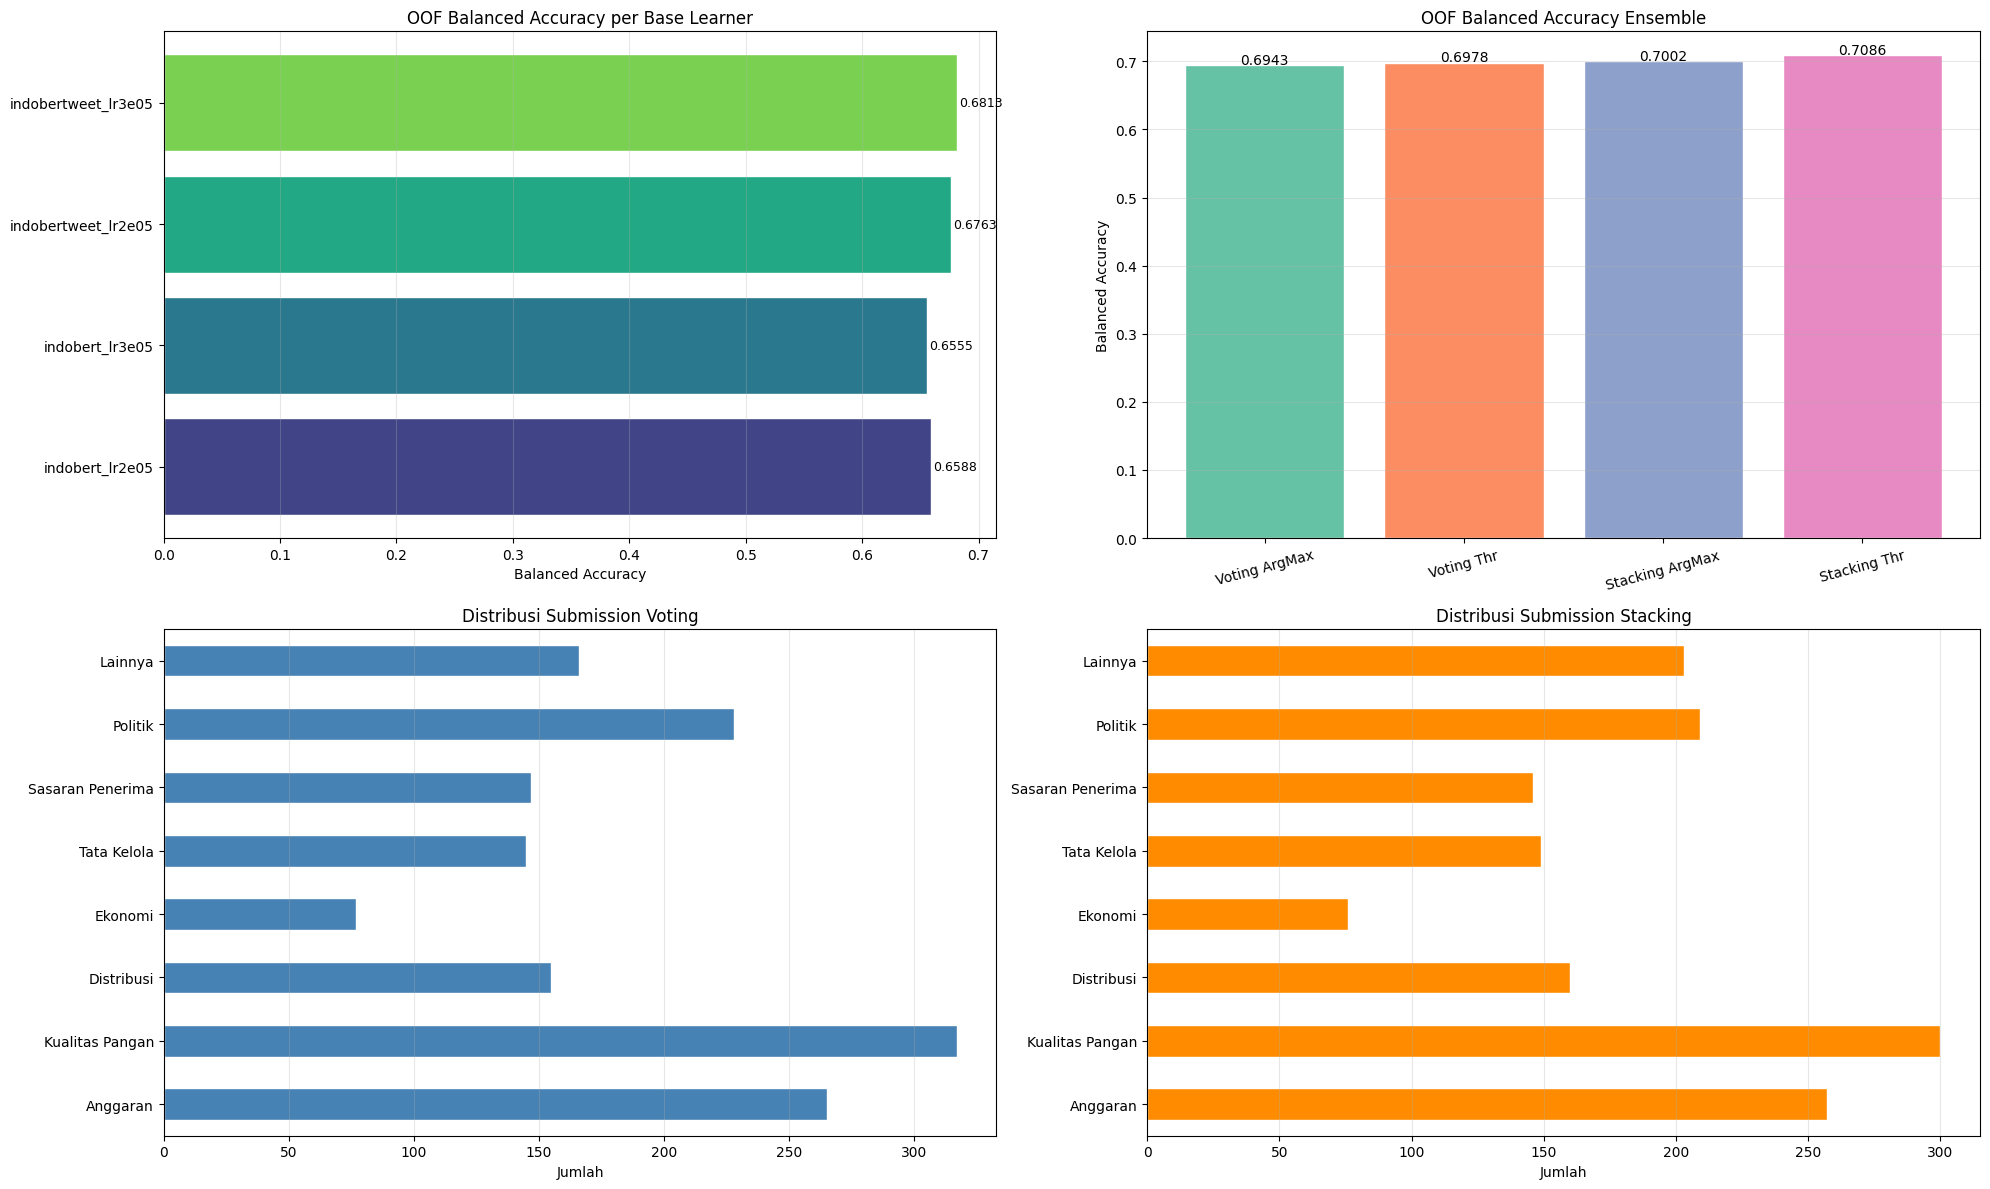

In [19]:
base_names = [item["run_name"] for item in run_manifest]
base_scores = [item["oof_argmax_score"] for item in run_manifest]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

axes[0, 0].barh(base_names, base_scores, color=sns.color_palette("viridis", len(base_names)), edgecolor="white")
axes[0, 0].set_title("OOF Balanced Accuracy per Base Learner")
axes[0, 0].set_xlabel("Balanced Accuracy")
axes[0, 0].grid(axis="x", alpha=0.3)
for i, score in enumerate(base_scores):
    axes[0, 0].text(score + 0.002, i, f"{score:.4f}", va="center", fontsize=9)

ensemble_names = ["Voting ArgMax", "Voting Thr", "Stacking ArgMax", "Stacking Thr"]
ensemble_scores = [voting_argmax_ba, voting_opt_ba, stacking_argmax_ba, stacking_opt_ba]
axes[0, 1].bar(ensemble_names, ensemble_scores, color=sns.color_palette("Set2", 4), edgecolor="white")
axes[0, 1].set_title("OOF Balanced Accuracy Ensemble")
axes[0, 1].set_ylabel("Balanced Accuracy")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].grid(axis="y", alpha=0.3)
for i, score in enumerate(ensemble_scores):
    axes[0, 1].text(i, score + 0.002, f"{score:.4f}", ha="center", fontsize=10)

pd.Series(voting_labels).value_counts().reindex(LABEL_NAMES, fill_value=0).plot(
    kind="barh", ax=axes[1, 0], color="steelblue", edgecolor="white"
)
axes[1, 0].set_title("Distribusi Submission Voting")
axes[1, 0].set_xlabel("Jumlah")
axes[1, 0].grid(axis="x", alpha=0.3)

pd.Series(stacking_labels).value_counts().reindex(LABEL_NAMES, fill_value=0).plot(
    kind="barh", ax=axes[1, 1], color="darkorange", edgecolor="white"
)
axes[1, 1].set_title("Distribusi Submission Stacking")
axes[1, 1].set_xlabel("Jumlah")
axes[1, 1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Ringkasan Akhir

In [20]:
print("=" * 80)
print("RINGKASAN AKHIR - ENSEMBLE INDOBERT + INDOBERTWEET")
print("=" * 80)
print(f"Jumlah base learner : {len(run_manifest)}")
print(f"Backbones           : {[m['model_name'] for m in MODEL_CONFIGS]}")
print(f"Learning rates      : {LEARNING_RATES}")
print(f"Regularisasi        : dropout={DROPOUT_RATE} | freeze={FREEZE_BOTTOM_N_LAYERS} | head LR x{HEAD_LR_MULTIPLIER:g}")
print(f"Early stopping      : {EARLY_STOPPING_METRIC} | greater_is_better={EARLY_STOPPING_GREATER_IS_BETTER}")
print(f"Augmentasi fold     : ekonomi target={ECONOMY_AUG_TARGET_PER_FOLD} | lainnya pendek target={LAINNYA_SHORT_AUG_TARGET_PER_FOLD}")
print(f"OOF shape           : {run_oof_probs.shape}")
print(f"Test shape          : {run_test_probs.shape}")
print("-" * 80)
print(f"Voting   OOF argmax : {voting_argmax_ba:.4f}")
print(f"Voting   OOF opt    : {voting_opt_ba:.4f}")
print(f"Stacking OOF argmax : {stacking_argmax_ba:.4f}")
print(f"Stacking OOF opt    : {stacking_opt_ba:.4f}")
print("-" * 80)
print(f"Voting submission   : {VOTING_SUBMISSION_FILE}")
print(f"Stacking submission : {STACKING_SUBMISSION_FILE}")
print(f"Manifest            : {MANIFEST_FILE}")
print("=" * 80)

RINGKASAN AKHIR - ENSEMBLE INDOBERT + INDOBERTWEET
Jumlah base learner : 4
Backbones           : ['indobenchmark/indobert-base-p2', 'indolem/indobertweet-base-uncased']
Learning rates      : [2e-05, 3e-05]
Regularisasi        : dropout=0.1 | freeze=0 | head LR x1
Early stopping      : balanced_accuracy | greater_is_better=True
Augmentasi fold     : ekonomi target=300 | lainnya pendek target=0
OOF shape           : (4, 5000, 8)
Test shape          : (4, 1500, 8)
--------------------------------------------------------------------------------
Voting   OOF argmax : 0.6943
Voting   OOF opt    : 0.6978
Stacking OOF argmax : 0.7002
Stacking OOF opt    : 0.7086
--------------------------------------------------------------------------------
Voting submission   : output/Last_Dance_DS_voting.xlsx
Stacking submission : output/Last_Dance_DS_stacking.xlsx
Manifest            : output/manifest_indobert_indobertweet.json
